# UniWallet Retention Validation — Bank Churn Analysis
Testing whether feature breadth or engagement drives retention,
as a follow-up to Team Catalyst Crew's ProduScope submission.
See README for full write-up.

In [10]:
import pandas as pd
import sqlite3

df = pd.read_csv('churn.csv')
print(df.columns.tolist())
print(df.head())

conn = sqlite3.connect('bank.db')
df.to_sql('customers', conn, if_exists='replace', index=False)

['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1        

10000

In [5]:
funnel = pd.read_sql("""
SELECT
  COUNT(*) AS total,
  SUM(CASE WHEN IsActiveMember=1 THEN 1 ELSE 0 END) AS active,
  SUM(CASE WHEN Balance>0 THEN 1 ELSE 0 END) AS funded,
  SUM(CASE WHEN Exited=0 THEN 1 ELSE 0 END) AS retained
FROM customers
""", conn)
print(funnel)


   total  active  funded  retained
0  10000    5151    6383      7963


## Does churn rate change with number of products held?

In [6]:
by_products = pd.read_sql("""
SELECT NumOfProducts,
  COUNT(*) AS customers,
  ROUND(SUM(Exited)*100.0/COUNT(*), 1) AS churn_rate_pct
FROM customers GROUP BY NumOfProducts
""", conn)
print(by_products)

   NumOfProducts  customers  churn_rate_pct
0              1       5084            27.7
1              2       4590             7.6
2              3        266            82.7
3              4         60           100.0


## Does active engagement reduce churn independent of product count?

In [7]:
by_active = pd.read_sql("""
SELECT IsActiveMember,
  COUNT(*) AS customers,
  ROUND(SUM(Exited)*100.0/COUNT(*), 1) AS churn_rate_pct
FROM customers GROUP BY IsActiveMember
""", conn)
print(by_active)

   IsActiveMember  customers  churn_rate_pct
0               0       4849            26.9
1               1       5151            14.3


In [8]:
by_geo = pd.read_sql("""
SELECT Geography, COUNT(*) AS customers,
  ROUND(SUM(Exited)*100.0/COUNT(*),1) AS churn_rate_pct
FROM customers GROUP BY Geography
""", conn)
print(by_geo)

  Geography  customers  churn_rate_pct
0    France       5014            16.2
1   Germany       2509            32.4
2     Spain       2477            16.7


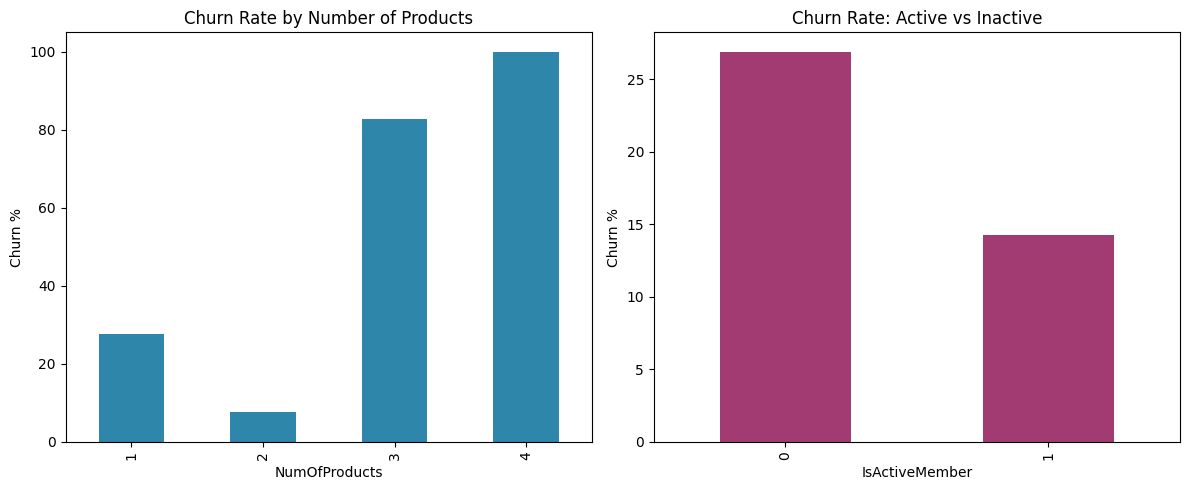

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5))
by_products.plot(x='NumOfProducts', y='churn_rate_pct', kind='bar', ax=ax[0], legend=False, color='#2E86AB')
ax[0].set_title('Churn Rate by Number of Products')
ax[0].set_ylabel('Churn %')

by_active.plot(x='IsActiveMember', y='churn_rate_pct', kind='bar', ax=ax[1], legend=False, color='#A23B72')
ax[1].set_title('Churn Rate: Active vs Inactive')
ax[1].set_ylabel('Churn %')

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150)
plt.show()

## Key takeaway
Retention peaks at **2 products (7.6% churn)** then collapses at **3-4 products
(82.7%, then 100% churn)**. Active engagement independently cuts churn
roughly in half. Full analysis and connection to UniWallet's MVP
prioritization in README.md.